In [1]:
import numpy as np
import pandas as pd
import  os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm import trange
from src.utils.portfolio_construction import *

working_dir = r'F:\Projects\Ask2.ai\Diffusion'
os.chdir(working_dir)
sns.set_style('whitegrid')

# Define the helper function

In [2]:
def GBM_MC(log_returns, n_simulations=1024, n_days=128, dt=1 / 252, S0=1):
    mu = log_returns.mean().values
    cov = log_returns.cov().values
    chol_cov = np.linalg.cholesky(cov)
    n_assets = len(mu)

    simulated_prices = np.zeros((n_days + 1, n_simulations, n_assets))
    simulated_prices[0] = S0

    drift = (mu - 0.5 * np.diag(cov)) * dt
    sqrt_dt = np.sqrt(dt)

    for t in range(1, n_days + 1):
        z = np.random.randn(n_simulations, n_assets)
        correlated_noise = z @ chol_cov.T
        log_return_step = drift + correlated_noise * sqrt_dt
        simulated_prices[t] = simulated_prices[t - 1] * np.exp(log_return_step)
        
    log_prices = np.log(simulated_prices)
    log_returns = log_prices[1:] - log_prices[:-1]
    reshaped_returns = log_returns.reshape(-1, simulated_prices.shape[2])
    return simulated_prices, reshaped_returns

In [3]:
def Heston_MC(
    log_returns,
    n_simulations=1024,
    n_days=128,
    dt=1 / 252,
    S0=1.0,
    v0=0.02,          
    kappa=3.0,        
    theta=0.02,      
    sigma=0.3,        
    rho=-0.5         
):
    """
    Multivariate Heston model simulator.

    Parameters:
    - log_returns: pd.DataFrame, historical log returns (T, n_assets)
    - n_simulations: int, number of Monte Carlo paths
    - n_days: int, simulation horizon
    - dt: float, time increment
    - S0: float or array-like, initial price(s)
    - v0, kappa, theta, sigma: float, Heston parameters (assumed equal across assets)
    - rho: float, within-asset correlation between price and volatility shocks

    Returns:
    - simulated_prices: np.ndarray, shape (n_days + 1, n_simulations, n_assets)
    - reshaped_returns: np.ndarray, shape ((n_days * n_simulations), n_assets)
    """
    mu = log_returns.mean().values
    cov = log_returns.cov().values
    n_assets = len(mu)

    # Price correlation (across assets)
    corr_matrix = log_returns.corr().values
    chol_corr = np.linalg.cholesky(corr_matrix)

    # Initial prices
    S0_array = np.full(n_assets, S0) if np.isscalar(S0) else np.array(S0)
    simulated_prices = np.zeros((n_days + 1, n_simulations, n_assets))
    simulated_prices[0] = S0_array

    # Initial variances
    simulated_variances = np.full((n_days + 1, n_simulations, n_assets), v0)

    sqrt_dt = np.sqrt(dt)

    for t in range(1, n_days + 1):
        z_price_raw = np.random.randn(n_simulations, n_assets)
        z_vol_raw = np.random.randn(n_simulations, n_assets)

        # Correlate vol shocks across assets
        z_vol = z_vol_raw @ chol_corr.T

        # Correlate price shocks across assets
        z_price_uncorr = z_price_raw @ chol_corr.T
        z_price = rho * z_vol + np.sqrt(1 - rho ** 2) * z_price_uncorr

        vt_prev = simulated_variances[t - 1]

        # CIR process for variance
        vt = (
            vt_prev +
            kappa * (theta - vt_prev) * dt +
            sigma * np.sqrt(np.maximum(vt_prev, 0)) * z_vol * sqrt_dt
        )
        vt = np.maximum(vt, 1e-8)

        drift = (mu - 0.5 * vt) * dt
        diffusion = np.sqrt(vt) * z_price * sqrt_dt

        log_return_step = drift + diffusion
        simulated_prices[t] = simulated_prices[t - 1] * np.exp(log_return_step)
        simulated_variances[t] = vt

    # Output log returns reshaped
    log_prices = np.log(simulated_prices)
    log_returns_out = log_prices[1:] - log_prices[:-1]
    reshaped_returns = log_returns_out.reshape(-1, n_assets)

    return simulated_prices, reshaped_returns

In [4]:
def mix_hist_and_simulated_data(hist_return, simulated_return, multiplier=1):
    assert hist_return.shape[1] == simulated_return.shape[1], "Mismatch in number of assets"
    hist_df = pd.DataFrame(hist_return)
    hist_df = pd.concat([hist_df] * multiplier, ignore_index=True)
    simulated_df = pd.DataFrame(simulated_return)
    combined_df = pd.concat([hist_df, simulated_df], ignore_index=True)
    return combined_df.values

In [5]:
def Sharpe_Ratio(returns, risk_free_rate=0.0, scale=252):
    return (returns - risk_free_rate).mean() * np.sqrt(scale) / (returns - risk_free_rate).std()

In [10]:
def compute_volatility(log_returns, scale = 252):
    assert log_returns.ndim == 2, "Input must be a 2D array (Time x Asset)"
    var_per_asset = np.var(log_returns, axis=0, ddof=1)  # unbiased estimator
    vol = np.sqrt(var_per_asset * scale)
    return vol

# Load the data

In [6]:
data = pd.read_csv('./warehouse/processed/benchmark_data_log_ret_10.csv')
data['date'] = pd.to_datetime(data['date'])

# Split the data into training and testing sets

In [7]:
train_len = 252 * 10
test_len = 128
train_start = data['date'][0]
train_end = data['date'][train_len]
test_start = data['date'][train_len]
test_end = data['date'][train_len + test_len]

train_data = data[(data['date'] >= train_start) & (data['date'] < train_end)]
test_data = data[(data['date'] >= test_start) & (data['date'] < test_end)]

# Simulate the price paths

In [8]:
simulated_prices, simulated_returns = GBM_MC(train_data.iloc[:, 1:])

In [44]:
simulated_prices_heston, simulated_returns_heston = Heston_MC(train_data.iloc[:, 1:])

In [53]:
mix_returns = mix_hist_and_simulated_data(train_data.iloc[:, 1:].values, simulated_returns_heston, multiplier=2)

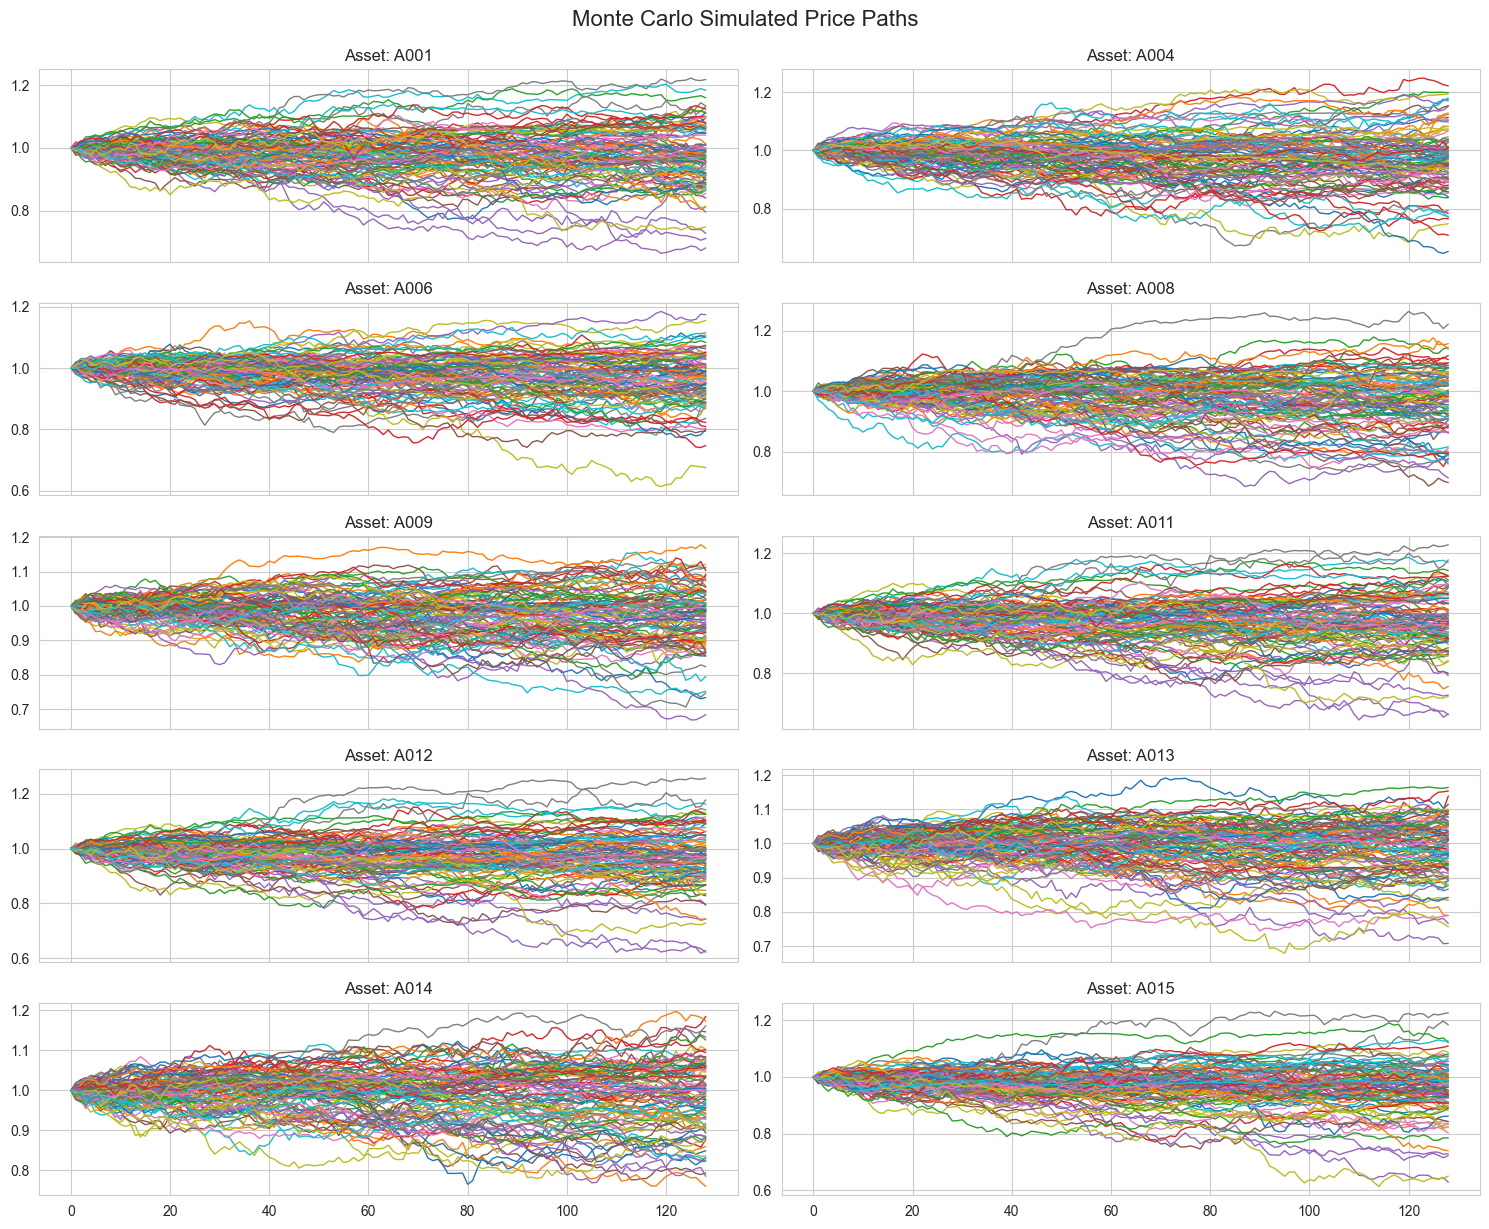

In [27]:
n_assets = simulated_prices_heston.shape[2]
n_paths_to_plot = 100  

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 12), sharex=True)
axes = axes.flatten()

time = range(simulated_prices_heston.shape[0])
asset_names = data.columns[1:]

for i in range(n_assets):
    ax = axes[i]
    for j in range(n_paths_to_plot):
        ax.plot(time, simulated_prices_heston[:, j, i], lw=1)
    ax.set_title(f'Asset: {asset_names[i]}')
    ax.grid(True)

plt.tight_layout()
plt.suptitle('Monte Carlo Simulated Price Paths', fontsize=16, y=1.02)
plt.show()

# Compute the portfolio

In [46]:
mc_GMV_weights = global_minimum_variance_portfolio(simulated_returns_heston)

In [47]:
mc_SR_weights = maximize_sharpe_ratio_portfolio(simulated_returns_heston, risk_free_rate=0.0)

In [48]:
mc_CVaR_weights = minimize_cvar_portfolio(simulated_returns_heston, alpha=0.95)

In [54]:
mix_GMV_weights = global_minimum_variance_portfolio(mix_returns)
mix_SR_weights = maximize_sharpe_ratio_portfolio(mix_returns, risk_free_rate=0.0)
mix_CVaR_weights = minimize_cvar_portfolio(mix_returns, alpha=0.95)

# Compute the portfolio returns

In [55]:
mc_GMV_returns = np.dot(test_data.iloc[:, 1:], mc_GMV_weights)
mc_SR_returns = np.dot(test_data.iloc[:, 1:], mc_SR_weights)
mc_CVaR_returns = np.dot(test_data.iloc[:, 1:], mc_CVaR_weights)
mix_GMV_returns = np.dot(test_data.iloc[:, 1:], mix_GMV_weights)
mix_SR_returns = np.dot(test_data.iloc[:, 1:], mix_SR_weights)
mix_CVaR_returns = np.dot(test_data.iloc[:, 1:], mix_CVaR_weights)
equal_weights = np.ones(n_assets) / n_assets
ew_returns = np.dot(test_data.iloc[:, 1:], equal_weights)

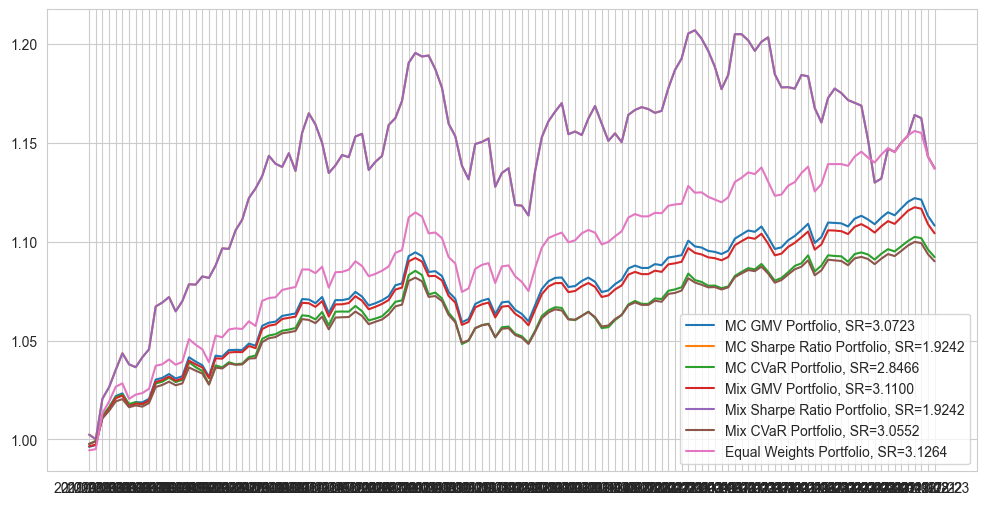

In [56]:
plt.figure(figsize=(12, 6))
plt.plot(test_data['date'], np.exp(mc_GMV_returns.cumsum()), label=f'MC GMV Portfolio, SR={Sharpe_Ratio(mc_GMV_returns):.4f}')
plt.plot(test_data['date'], np.exp(mc_SR_returns.cumsum()), label=f'MC Sharpe Ratio Portfolio, SR={Sharpe_Ratio(mc_SR_returns):.4f}')
plt.plot(test_data['date'], np.exp(mc_CVaR_returns.cumsum()), label=f'MC CVaR Portfolio, SR={Sharpe_Ratio(mc_CVaR_returns):.4f}')
plt.plot(test_data['date'], np.exp(mix_GMV_returns.cumsum()), label=f'Mix GMV Portfolio, SR={Sharpe_Ratio(mix_GMV_returns):.4f}')
plt.plot(test_data['date'], np.exp(mix_SR_returns.cumsum()), label=f'Mix Sharpe Ratio Portfolio, SR={Sharpe_Ratio(mix_SR_returns):.4f}')
plt.plot(test_data['date'], np.exp(mix_CVaR_returns.cumsum()), label=f'Mix CVaR Portfolio, SR={Sharpe_Ratio(mix_CVaR_returns):.4f}')
plt.plot(test_data['date'], np.exp(ew_returns.cumsum()), label=f'Equal Weights Portfolio, SR={Sharpe_Ratio(ew_returns):.4f}')
plt.legend()

# Diffusion 

In [15]:
path = r'F:\Projects\Ask2.ai\Diffusion\test_results'
folder_names = [name for name in os.listdir(path) if os.path.isdir(os.path.join(path, name))]

In [16]:
test_folder_names = [
    'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_sd20010102_ed20100831_ds0_cmTrue_ceTrue_ipTrue_RoPE_10mfs',
    'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_sd20010629_ed20110225_ds0_cmTrue_ceTrue_ipTrue_RoPE_10mfs',
    'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_sd20011226_ed20110824_ds0_cmTrue_ceTrue_ipTrue_RoPE_10mfs',
    'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_sd20020624_ed20120220_ds0_cmTrue_ceTrue_ipTrue_RoPE_10mfs',
    'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_sd20021219_ed20120816_ds0_cmTrue_ceTrue_ipTrue_RoPE_10mfs',
    'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_sd20030617_ed20130212_ds0_cmTrue_ceTrue_ipTrue_RoPE_10mfs',
    'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_sd20031212_ed20130809_ds0_cmTrue_ceTrue_ipTrue_RoPE_10mfs',
    'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_sd20040609_ed20140205_ds0_cmTrue_ceTrue_ipTrue_RoPE_10mfs',
    'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_sd20041206_ed20140804_ds0_cmTrue_ceTrue_ipTrue_RoPE_10mfs',
    'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_sd20050602_ed20150129_ds0_cmTrue_ceTrue_ipTrue_RoPE_10mfs',
    'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_sd20051129_ed20150728_ds0_cmTrue_ceTrue_ipTrue_RoPE_10mfs',
    'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_sd20060526_ed20160122_ds0_cmTrue_ceTrue_ipTrue_RoPE_10mfs',
    'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_sd20061122_ed20160720_ds0_cmTrue_ceTrue_ipTrue_RoPE_10mfs',
    'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_sd20070521_ed20170116_ds0_cmTrue_ceTrue_ipTrue_RoPE_10mfs',
    'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_sd20071115_ed20170713_ds0_cmTrue_ceTrue_ipTrue_RoPE_10mfs',
    'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_sd20080513_ed20180109_ds0_cmTrue_ceTrue_ipTrue_RoPE_10mfs',
    'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_sd20081107_ed20180706_ds0_cmTrue_ceTrue_ipTrue_RoPE_10mfs',
    'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_sd20090506_ed20190102_ds0_cmTrue_ceTrue_ipTrue_RoPE_10mfs',
    'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_sd20091102_ed20190701_ds0_cmTrue_ceTrue_ipTrue_RoPE_10mfs',
    'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_sd20100429_ed20191226_ds0_cmTrue_ceTrue_ipTrue_RoPE_10mfs',
    'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_sd20101026_ed20200623_ds0_cmTrue_ceTrue_ipTrue_RoPE_10mfs',
    'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_sd20110422_ed20201218_ds0_cmTrue_ceTrue_ipTrue_RoPE_10mfs',
    'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_sd20111019_ed20210616_ds0_cmTrue_ceTrue_ipTrue_RoPE_10mfs',
    'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_sd20120416_ed20211213_ds0_cmTrue_ceTrue_ipTrue_RoPE_10mfs',
    'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_sd20121011_ed20220609_ds0_cmTrue_ceTrue_ipTrue_RoPE_10mfs'
]
generated_data_paths = [f'./test_results/{folder_name}/450_discrete_DDPM_0.7473/generated_data.csv' for folder_name in test_folder_names]
generated_data = [pd.read_csv(path) for path in generated_data_paths]

# Rolling window

In [59]:
data = pd.read_csv('./warehouse/processed/benchmark_data_log_ret_10.csv')
dates = data.iloc[1:, 0]
dates = [str(date) for date in dates]
dataset_len = 10 * 252
dataset_lapse = 128
start_idx = np.arange(0, len(dates), dataset_lapse)
end_idx = np.arange(dataset_len, len(dates), dataset_lapse)
start_idx = start_idx[:len(end_idx)]
start_dates = [dates[i] for i in start_idx[:-1]]
end_dates = [dates[i] for i in end_idx[:-1]]
test_start_idx = end_idx[:-1] + 1
test_end_idx = test_start_idx + 128
test_start_dates = [dates[i] for i in test_start_idx]
test_end_dates = [dates[i] for i in test_end_idx]

In [61]:
df_results = pd.DataFrame(columns=['date',
                                   'GBM_GMV_returns',
                                   'GBM_SR_returns',
                                   'GBM_CVaR_returns',
                                   'GBM_GMV_returns_mix',
                                   'GBM_SR_returns_mix',
                                   'GBM_CVaR_returns_mix',
                                   'Heston_GMV_returns',
                                   'Heston_SR_returns',
                                   'Heston_CVaR_returns',
                                   'Heston_GMV_returns_mix',
                                   'Heston_SR_returns_mix',
                                   'Heston_CVaR_returns_mix',
                                   'diffusion_GMV_returns',
                                   'diffusion_SR_returns',
                                   'diffusion_CVaR_returns',
                                   'diffusion_GMV_returns_mix',
                                   'diffusion_SR_returns_mix',
                                   'diffusion_CVaR_returns_mix',
                                   'ew_returns'])
for i in trange(len(start_dates)):
    train_data = data[(data['date'] >= start_dates[i]) & (data['date'] <= end_dates[i])]
    test_data = data[(data['date'] >= test_start_dates[i]) & (data['date'] < test_end_dates[i])]
    test_dates = test_data['date']
    _, GBM_simulated_returns = GBM_MC(train_data.iloc[:, 1:])
    GBM_mix_returns = mix_hist_and_simulated_data(train_data.iloc[:, 1:].values, GBM_simulated_returns, multiplier=1)
    _, Heston_simulated_returns = Heston_MC(train_data.iloc[:, 1:])
    Heston_mix_returns = mix_hist_and_simulated_data(train_data.iloc[:, 1:].values, Heston_simulated_returns, multiplier=1)
    diffusion_simulated_returns = generated_data[i]
    diffusion_mix_returns = mix_hist_and_simulated_data(train_data.iloc[:, 1:].values, diffusion_simulated_returns.values, multiplier=1)

    GBM_GMV_weights = global_minimum_variance_portfolio(GBM_simulated_returns)
    GBM_SR_weights = maximize_sharpe_ratio_portfolio(GBM_simulated_returns, risk_free_rate=0.0)
    GBM_CVaR_weights = minimize_cvar_portfolio(GBM_simulated_returns, alpha=0.95)
    
    GBM_GMV_mix_weights = global_minimum_variance_portfolio(GBM_mix_returns)
    GBM_SR_mix_weights = maximize_sharpe_ratio_portfolio(GBM_mix_returns, risk_free_rate=0.0)
    GBM_CVaR_mix_weights = minimize_cvar_portfolio(GBM_mix_returns, alpha=0.95)
    
    Heston_GMV_weights = global_minimum_variance_portfolio(Heston_simulated_returns)
    Heston_SR_weights = maximize_sharpe_ratio_portfolio(Heston_simulated_returns, risk_free_rate=0.0)
    Heston_CVaR_weights = minimize_cvar_portfolio(Heston_simulated_returns, alpha=0.95)
    
    Heston_GMV_mix_weights = global_minimum_variance_portfolio(Heston_mix_returns)
    Heston_SR_mix_weights = maximize_sharpe_ratio_portfolio(Heston_mix_returns, risk_free_rate=0.0)
    Heston_CVaR_mix_weights = minimize_cvar_portfolio(Heston_mix_returns, alpha=0.95)
    
    diffusion_GMV_weights = global_minimum_variance_portfolio(diffusion_simulated_returns.values)
    diffusion_SR_weights = maximize_sharpe_ratio_portfolio(diffusion_simulated_returns.values, risk_free_rate=0.0)
    diffusion_CVaR_weights = minimize_cvar_portfolio(diffusion_simulated_returns.values, alpha=0.95)
    
    diffusion_GMV_mix_weights = global_minimum_variance_portfolio(diffusion_mix_returns)
    diffusion_SR_mix_weights = maximize_sharpe_ratio_portfolio(diffusion_mix_returns, risk_free_rate=0.0)
    diffusion_CVaR_mix_weights = minimize_cvar_portfolio(diffusion_mix_returns, alpha=0.95)
    
    equal_weights = np.ones(10) / 10
    
    GBM_GMV_returns = np.dot(test_data.iloc[:, 1:], GBM_GMV_weights)
    GBM_SR_returns = np.dot(test_data.iloc[:, 1:], GBM_SR_weights)
    GBM_CVaR_returns = np.dot(test_data.iloc[:, 1:], GBM_CVaR_weights)
    
    GBM_GMV_mix_returns = np.dot(test_data.iloc[:, 1:], GBM_GMV_mix_weights)
    GBM_SR_mix_returns = np.dot(test_data.iloc[:, 1:], GBM_SR_mix_weights)
    GBM_CVaR_mix_returns = np.dot(test_data.iloc[:, 1:], GBM_CVaR_mix_weights)
    
    Heston_GMV_returns = np.dot(test_data.iloc[:, 1:], Heston_GMV_weights)
    Heston_SR_returns = np.dot(test_data.iloc[:, 1:], Heston_SR_weights)
    Heston_CVaR_returns = np.dot(test_data.iloc[:, 1:], Heston_CVaR_weights)
    
    Heston_GMV_mix_returns = np.dot(test_data.iloc[:, 1:], Heston_GMV_mix_weights)
    Heston_SR_mix_returns = np.dot(test_data.iloc[:, 1:], Heston_SR_mix_weights)
    Heston_CVaR_mix_returns = np.dot(test_data.iloc[:, 1:], Heston_CVaR_mix_weights)
    
    diffusion_GMV_returns = np.dot(test_data.iloc[:, 1:], diffusion_GMV_weights)
    diffusion_SR_returns = np.dot(test_data.iloc[:, 1:], diffusion_SR_weights)
    diffusion_CVaR_returns = np.dot(test_data.iloc[:, 1:], diffusion_CVaR_weights)
    
    diffusion_GMV_mix_returns = np.dot(test_data.iloc[:, 1:], diffusion_GMV_mix_weights)
    diffusion_SR_mix_returns = np.dot(test_data.iloc[:, 1:], diffusion_SR_mix_weights)
    diffusion_CVaR_mix_returns = np.dot(test_data.iloc[:, 1:], diffusion_CVaR_mix_weights)
    
    ew_returns = np.dot(test_data.iloc[:, 1:], equal_weights)
    
    df_result = pd.DataFrame({
        'date': pd.to_datetime(test_dates),
        'GBM_GMV_returns': GBM_GMV_returns,
        'GBM_SR_returns': GBM_SR_returns,
        'GBM_CVaR_returns': GBM_CVaR_returns,
        'GBM_GMV_returns_mix': GBM_GMV_mix_returns,
        'GBM_SR_returns_mix': GBM_SR_mix_returns,
        'GBM_CVaR_returns_mix': GBM_CVaR_mix_returns,
        'Heston_GMV_returns': Heston_GMV_returns,
        'Heston_SR_returns': Heston_SR_returns,
        'Heston_CVaR_returns': Heston_CVaR_returns,
        'Heston_GMV_returns_mix': Heston_GMV_mix_returns,
        'Heston_SR_returns_mix': Heston_SR_mix_returns,
        'Heston_CVaR_returns_mix': Heston_CVaR_mix_returns,
        'diffusion_GMV_returns': diffusion_GMV_returns,
        'diffusion_SR_returns': diffusion_SR_returns,
        'diffusion_CVaR_returns': diffusion_CVaR_returns,
        'diffusion_GMV_returns_mix': diffusion_GMV_mix_returns,
        'diffusion_SR_returns_mix': diffusion_SR_mix_returns,
        'diffusion_CVaR_returns_mix': diffusion_CVaR_mix_returns,
        'ew_returns': ew_returns
    })
    df_results = pd.concat([df_results, df_result])

  0%|          | 0/24 [00:00<?, ?it/s]C:\Users\Admin\AppData\Local\Temp\ipykernel_17684\1733263559.py:106: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_results = pd.concat([df_results, df_result])
100%|██████████| 24/24 [11:49<00:00, 29.58s/it]


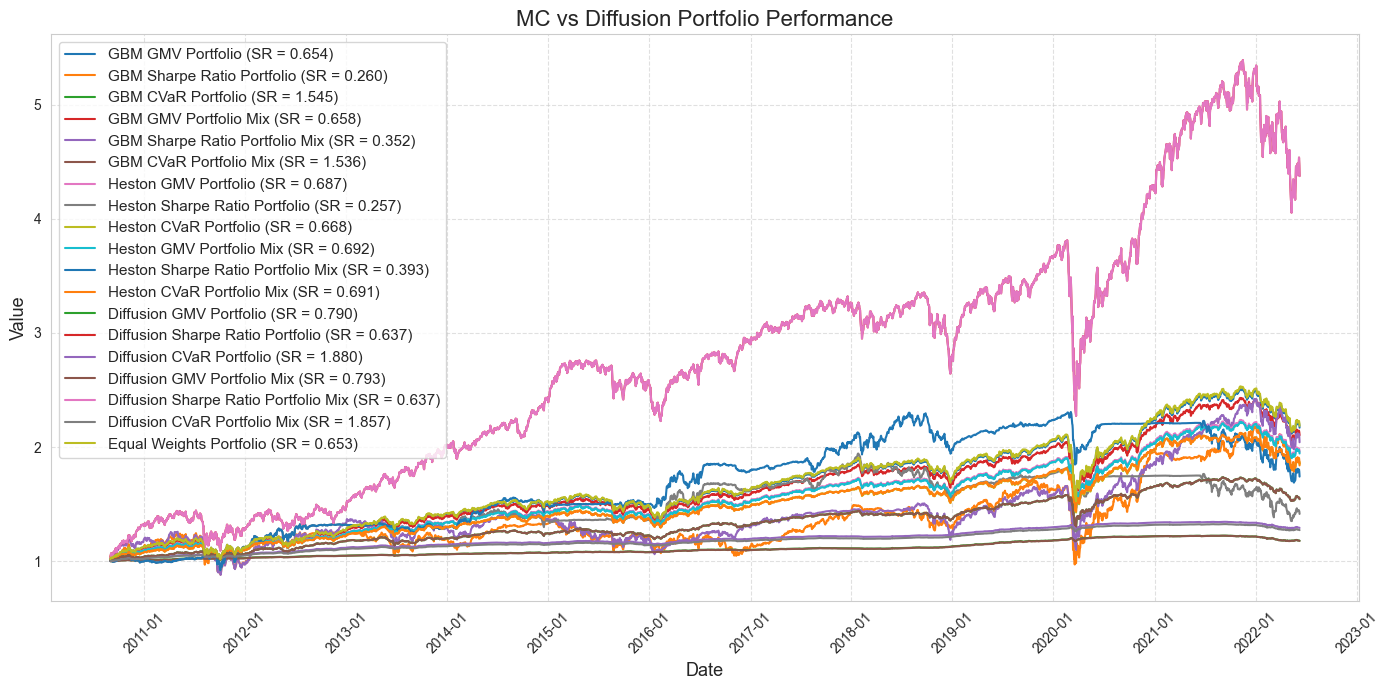

In [62]:
plt.figure(figsize=(14, 7))

portfolios = [
    ("GBM_GMV_returns", "GBM GMV Portfolio"),
    ("GBM_SR_returns", "GBM Sharpe Ratio Portfolio"),
    ("GBM_CVaR_returns", "GBM CVaR Portfolio"),
    ("GBM_GMV_returns_mix", "GBM GMV Portfolio Mix"),
    ("GBM_SR_returns_mix", "GBM Sharpe Ratio Portfolio Mix"),
    ("GBM_CVaR_returns_mix", "GBM CVaR Portfolio Mix"),
    ("Heston_GMV_returns", "Heston GMV Portfolio"),
    ("Heston_SR_returns", "Heston Sharpe Ratio Portfolio"),
    ("Heston_CVaR_returns", "Heston CVaR Portfolio"),
    ("Heston_GMV_returns_mix", "Heston GMV Portfolio Mix"),
    ("Heston_SR_returns_mix", "Heston Sharpe Ratio Portfolio Mix"),
    ("Heston_CVaR_returns_mix", "Heston CVaR Portfolio Mix"),
    ("diffusion_GMV_returns", "Diffusion GMV Portfolio"),
    ("diffusion_SR_returns", "Diffusion Sharpe Ratio Portfolio"),
    ("diffusion_CVaR_returns", "Diffusion CVaR Portfolio"),
    ("diffusion_GMV_returns_mix", "Diffusion GMV Portfolio Mix"),
    ("diffusion_SR_returns_mix", "Diffusion Sharpe Ratio Portfolio Mix"),
    ("diffusion_CVaR_returns_mix", "Diffusion CVaR Portfolio Mix"),
    ("ew_returns", "Equal Weights Portfolio")
]

for col, label in portfolios:
    cumulative_returns = np.exp(df_results[col].cumsum())
    sharpe = Sharpe_Ratio(df_results[col])
    plt.plot(df_results['date'], cumulative_returns, label=f"{label} (SR = {sharpe:.3f})")
    
plt.title("MC vs Diffusion Portfolio Performance", fontsize=16)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Value", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=20))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("./plots/diffusion_replace_mc/MC_vs_Diffusion_Portfolio_Performance.png")
plt.show()

# min weight = 0.05

In [63]:
df_results = pd.DataFrame(columns=['date',
                                   'GBM_GMV_returns',
                                   'GBM_SR_returns',
                                   'GBM_CVaR_returns',
                                   'GBM_GMV_returns_mix',
                                   'GBM_SR_returns_mix',
                                   'GBM_CVaR_returns_mix',
                                   'Heston_GMV_returns',
                                   'Heston_SR_returns',
                                   'Heston_CVaR_returns',
                                   'Heston_GMV_returns_mix',
                                   'Heston_SR_returns_mix',
                                   'Heston_CVaR_returns_mix',
                                   'diffusion_GMV_returns',
                                   'diffusion_SR_returns',
                                   'diffusion_CVaR_returns',
                                   'diffusion_GMV_returns_mix',
                                   'diffusion_SR_returns_mix',
                                   'diffusion_CVaR_returns_mix',
                                   'ew_returns'])
for i in trange(len(start_dates)):
    train_data = data[(data['date'] >= start_dates[i]) & (data['date'] <= end_dates[i])]
    test_data = data[(data['date'] >= test_start_dates[i]) & (data['date'] < test_end_dates[i])]
    test_dates = test_data['date']
    _, GBM_simulated_returns = GBM_MC(train_data.iloc[:, 1:])
    GBM_mix_returns = mix_hist_and_simulated_data(train_data.iloc[:, 1:].values, GBM_simulated_returns, multiplier=1)
    _, Heston_simulated_returns = Heston_MC(train_data.iloc[:, 1:])
    Heston_mix_returns = mix_hist_and_simulated_data(train_data.iloc[:, 1:].values, Heston_simulated_returns, multiplier=1)
    diffusion_simulated_returns = generated_data[i]
    diffusion_mix_returns = mix_hist_and_simulated_data(train_data.iloc[:, 1:].values, diffusion_simulated_returns.values, multiplier=1)

    GBM_GMV_weights = global_minimum_variance_portfolio(GBM_simulated_returns, min_weight=0.05)
    GBM_SR_weights = maximize_sharpe_ratio_portfolio(GBM_simulated_returns, risk_free_rate=0.0, min_weight=0.05)
    GBM_CVaR_weights = minimize_cvar_portfolio(GBM_simulated_returns, alpha=0.95, min_weight=0.05)
    
    GBM_GMV_mix_weights = global_minimum_variance_portfolio(GBM_mix_returns, min_weight=0.05)
    GBM_SR_mix_weights = maximize_sharpe_ratio_portfolio(GBM_mix_returns, risk_free_rate=0.0, min_weight=0.05)
    GBM_CVaR_mix_weights = minimize_cvar_portfolio(GBM_mix_returns, alpha=0.95, min_weight=0.05)
    
    Heston_GMV_weights = global_minimum_variance_portfolio(Heston_simulated_returns, min_weight=0.05)
    Heston_SR_weights = maximize_sharpe_ratio_portfolio(Heston_simulated_returns, risk_free_rate=0.0, min_weight=0.05)
    Heston_CVaR_weights = minimize_cvar_portfolio(Heston_simulated_returns, alpha=0.95, min_weight=0.05)
    
    Heston_GMV_mix_weights = global_minimum_variance_portfolio(Heston_mix_returns, min_weight=0.05)
    Heston_SR_mix_weights = maximize_sharpe_ratio_portfolio(Heston_mix_returns, risk_free_rate=0.0, min_weight=0.05)
    Heston_CVaR_mix_weights = minimize_cvar_portfolio(Heston_mix_returns, alpha=0.95, min_weight=0.05)
    
    diffusion_GMV_weights = global_minimum_variance_portfolio(diffusion_simulated_returns.values, min_weight=0.05)
    diffusion_SR_weights = maximize_sharpe_ratio_portfolio(diffusion_simulated_returns.values, risk_free_rate=0.0, min_weight=0.05)
    diffusion_CVaR_weights = minimize_cvar_portfolio(diffusion_simulated_returns.values, alpha=0.95, min_weight=0.05)
    
    diffusion_GMV_mix_weights = global_minimum_variance_portfolio(diffusion_mix_returns, min_weight=0.05)
    diffusion_SR_mix_weights = maximize_sharpe_ratio_portfolio(diffusion_mix_returns, risk_free_rate=0.0, min_weight=0.05)
    diffusion_CVaR_mix_weights = minimize_cvar_portfolio(diffusion_mix_returns, alpha=0.95, min_weight=0.05)
    
    equal_weights = np.ones(10) / 10
    
    GBM_GMV_returns = np.dot(test_data.iloc[:, 1:], GBM_GMV_weights)
    GBM_SR_returns = np.dot(test_data.iloc[:, 1:], GBM_SR_weights)
    GBM_CVaR_returns = np.dot(test_data.iloc[:, 1:], GBM_CVaR_weights)
    
    GBM_GMV_mix_returns = np.dot(test_data.iloc[:, 1:], GBM_GMV_mix_weights)
    GBM_SR_mix_returns = np.dot(test_data.iloc[:, 1:], GBM_SR_mix_weights)
    GBM_CVaR_mix_returns = np.dot(test_data.iloc[:, 1:], GBM_CVaR_mix_weights)
    
    Heston_GMV_returns = np.dot(test_data.iloc[:, 1:], Heston_GMV_weights)
    Heston_SR_returns = np.dot(test_data.iloc[:, 1:], Heston_SR_weights)
    Heston_CVaR_returns = np.dot(test_data.iloc[:, 1:], Heston_CVaR_weights)
    
    Heston_GMV_mix_returns = np.dot(test_data.iloc[:, 1:], Heston_GMV_mix_weights)
    Heston_SR_mix_returns = np.dot(test_data.iloc[:, 1:], Heston_SR_mix_weights)
    Heston_CVaR_mix_returns = np.dot(test_data.iloc[:, 1:], Heston_CVaR_mix_weights)
    
    diffusion_GMV_returns = np.dot(test_data.iloc[:, 1:], diffusion_GMV_weights)
    diffusion_SR_returns = np.dot(test_data.iloc[:, 1:], diffusion_SR_weights)
    diffusion_CVaR_returns = np.dot(test_data.iloc[:, 1:], diffusion_CVaR_weights)
    
    diffusion_GMV_mix_returns = np.dot(test_data.iloc[:, 1:], diffusion_GMV_mix_weights)
    diffusion_SR_mix_returns = np.dot(test_data.iloc[:, 1:], diffusion_SR_mix_weights)
    diffusion_CVaR_mix_returns = np.dot(test_data.iloc[:, 1:], diffusion_CVaR_mix_weights)
    
    ew_returns = np.dot(test_data.iloc[:, 1:], equal_weights)
    
    df_result = pd.DataFrame({
        'date': pd.to_datetime(test_dates),
        'GBM_GMV_returns': GBM_GMV_returns,
        'GBM_SR_returns': GBM_SR_returns,
        'GBM_CVaR_returns': GBM_CVaR_returns,
        'GBM_GMV_returns_mix': GBM_GMV_mix_returns,
        'GBM_SR_returns_mix': GBM_SR_mix_returns,
        'GBM_CVaR_returns_mix': GBM_CVaR_mix_returns,
        'Heston_GMV_returns': Heston_GMV_returns,
        'Heston_SR_returns': Heston_SR_returns,
        'Heston_CVaR_returns': Heston_CVaR_returns,
        'Heston_GMV_returns_mix': Heston_GMV_mix_returns,
        'Heston_SR_returns_mix': Heston_SR_mix_returns,
        'Heston_CVaR_returns_mix': Heston_CVaR_mix_returns,
        'diffusion_GMV_returns': diffusion_GMV_returns,
        'diffusion_SR_returns': diffusion_SR_returns,
        'diffusion_CVaR_returns': diffusion_CVaR_returns,
        'diffusion_GMV_returns_mix': diffusion_GMV_mix_returns,
        'diffusion_SR_returns_mix': diffusion_SR_mix_returns,
        'diffusion_CVaR_returns_mix': diffusion_CVaR_mix_returns,
        'ew_returns': ew_returns
    })
    df_results = pd.concat([df_results, df_result])

  0%|          | 0/24 [00:00<?, ?it/s]C:\Users\Admin\AppData\Local\Temp\ipykernel_17684\3285808369.py:106: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_results = pd.concat([df_results, df_result])
100%|██████████| 24/24 [08:24<00:00, 21.01s/it]


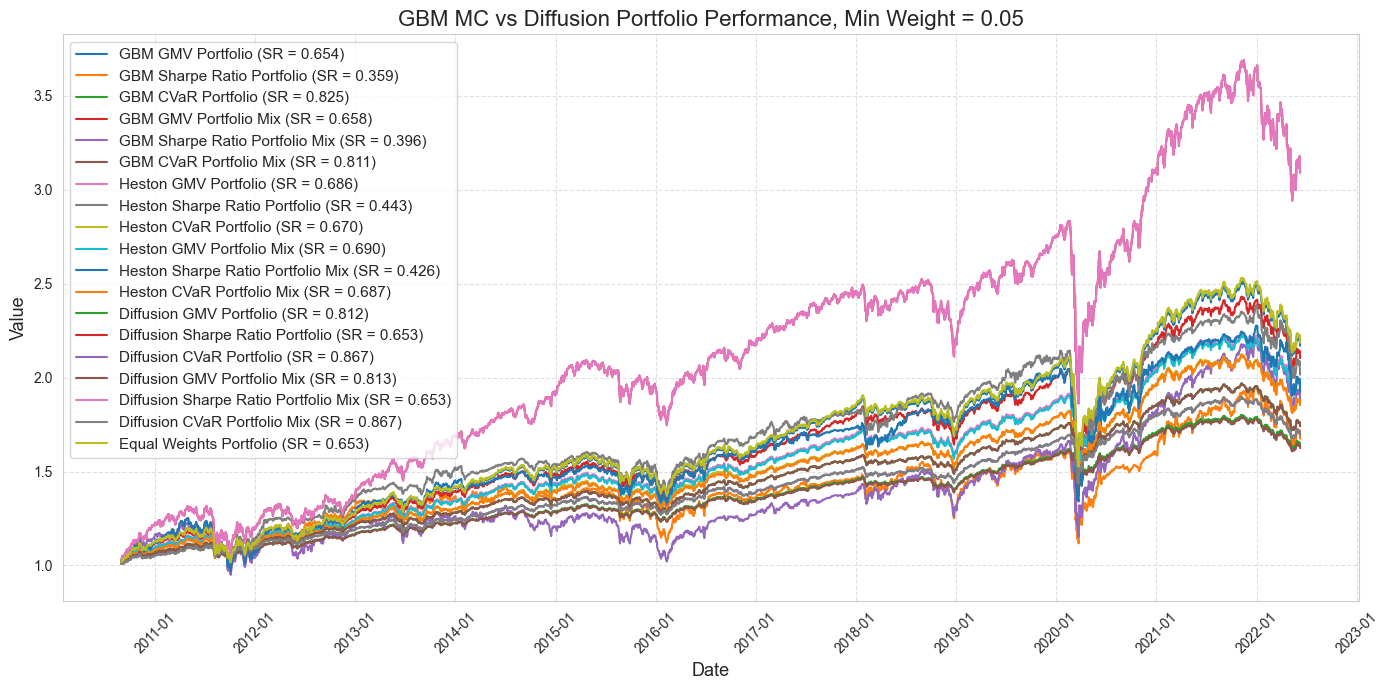

In [64]:
plt.figure(figsize=(14, 7))

portfolios = [
    ("GBM_GMV_returns", "GBM GMV Portfolio"),
    ("GBM_SR_returns", "GBM Sharpe Ratio Portfolio"),
    ("GBM_CVaR_returns", "GBM CVaR Portfolio"),
    ("GBM_GMV_returns_mix", "GBM GMV Portfolio Mix"),
    ("GBM_SR_returns_mix", "GBM Sharpe Ratio Portfolio Mix"),
    ("GBM_CVaR_returns_mix", "GBM CVaR Portfolio Mix"),
    ("Heston_GMV_returns", "Heston GMV Portfolio"),
    ("Heston_SR_returns", "Heston Sharpe Ratio Portfolio"),
    ("Heston_CVaR_returns", "Heston CVaR Portfolio"),
    ("Heston_GMV_returns_mix", "Heston GMV Portfolio Mix"),
    ("Heston_SR_returns_mix", "Heston Sharpe Ratio Portfolio Mix"),
    ("Heston_CVaR_returns_mix", "Heston CVaR Portfolio Mix"),
    ("diffusion_GMV_returns", "Diffusion GMV Portfolio"),
    ("diffusion_SR_returns", "Diffusion Sharpe Ratio Portfolio"),
    ("diffusion_CVaR_returns", "Diffusion CVaR Portfolio"),
    ("diffusion_GMV_returns_mix", "Diffusion GMV Portfolio Mix"),
    ("diffusion_SR_returns_mix", "Diffusion Sharpe Ratio Portfolio Mix"),
    ("diffusion_CVaR_returns_mix", "Diffusion CVaR Portfolio Mix"),
    ("ew_returns", "Equal Weights Portfolio")
]

for col, label in portfolios:
    cumulative_returns = np.exp(df_results[col].cumsum())
    sharpe = Sharpe_Ratio(df_results[col])
    plt.plot(df_results['date'], cumulative_returns, label=f"{label} (SR = {sharpe:.3f})")
    
plt.title("GBM MC vs Diffusion Portfolio Performance, Min Weight = 0.05", fontsize=16)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Value", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=20))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("./plots/diffusion_replace_mc/MC_vs_Diffusion_Portfolio_Performance_minweight0.05.png")
plt.show()

# Volatility Prediction

# Rolling window

In [17]:
data = pd.read_csv('./warehouse/processed/benchmark_data_log_ret_10.csv')
dates = data.iloc[1:, 0]
dates = [str(date) for date in dates]
dataset_len = 10 * 252
dataset_lapse = 128
start_idx = np.arange(0, len(dates), dataset_lapse)
end_idx = np.arange(dataset_len, len(dates), dataset_lapse)
start_idx = start_idx[:len(end_idx)]
start_dates = [dates[i] for i in start_idx[:-1]]
end_dates = [dates[i] for i in end_idx[:-1]]
test_start_idx = end_idx[:-1] + 1
test_end_idx = test_start_idx + 128
test_start_dates = [dates[i] for i in test_start_idx]
test_end_dates = [dates[i] for i in test_end_idx]

In [21]:
df_results = pd.DataFrame(columns=['test_start_date',
                                   'test_end_date',
                                   'GBM_vol_mse',
                                   'GBM_vol_mse_mix',
                                   'Heston_vol_mse',
                                   'Heston_vol_mse_mix',
                                   'diffusion_vol_mse',
                                   'diffusion_vol_mse_mix',
                                   'hist_vol_mse'])
for i in trange(len(start_dates)):
    train_data = data[(data['date'] >= start_dates[i]) & (data['date'] <= end_dates[i])]
    test_data = data[(data['date'] >= test_start_dates[i]) & (data['date'] < test_end_dates[i])]
    _, GBM_simulated_returns = GBM_MC(train_data.iloc[:, 1:])
    GBM_mix_returns = mix_hist_and_simulated_data(train_data.iloc[:, 1:].values, GBM_simulated_returns, multiplier=1)
    _, Heston_simulated_returns = Heston_MC(train_data.iloc[:, 1:])
    Heston_mix_returns = mix_hist_and_simulated_data(train_data.iloc[:, 1:].values, Heston_simulated_returns, multiplier=1)
    diffusion_simulated_returns = generated_data[i]
    diffusion_mix_returns = mix_hist_and_simulated_data(train_data.iloc[:, 1:].values, diffusion_simulated_returns.values, multiplier=1)
    
    MSE = lambda x, y: np.mean((x - y) ** 2)
    GBM_vol_mse = MSE(compute_volatility(test_data.iloc[:, 1:]), compute_volatility(GBM_simulated_returns))
    GBM_vol_mse_mix = MSE(compute_volatility(test_data.iloc[:, 1:]), compute_volatility(GBM_mix_returns))
    Heston_vol_mse = MSE(compute_volatility(test_data.iloc[:, 1:]), compute_volatility(Heston_simulated_returns))
    Heston_vol_mse_mix = MSE(compute_volatility(test_data.iloc[:, 1:]), compute_volatility(Heston_mix_returns))
    diffusion_vol_mse = MSE(compute_volatility(test_data.iloc[:, 1:]), compute_volatility(diffusion_simulated_returns.values))
    diffusion_vol_mse_mix = MSE(compute_volatility(test_data.iloc[:, 1:]), compute_volatility(diffusion_mix_returns))
    hist_vol_mse = MSE(compute_volatility(test_data.iloc[:, 1:]), compute_volatility(train_data.iloc[:, 1:]))
    
    df_result = pd.DataFrame([{
    'test_start_date': pd.to_datetime(test_start_dates[i]),
    'test_end_date': pd.to_datetime(test_end_dates[i]),
    'GBM_vol_mse': GBM_vol_mse,
    'GBM_vol_mse_mix': GBM_vol_mse_mix,
    'Heston_vol_mse': Heston_vol_mse,
    'Heston_vol_mse_mix': Heston_vol_mse_mix,
    'diffusion_vol_mse': diffusion_vol_mse,
    'diffusion_vol_mse_mix': diffusion_vol_mse_mix,
    'hist_vol_mse': hist_vol_mse
    }])
    df_results = pd.concat([df_results, df_result])

  0%|          | 0/24 [00:00<?, ?it/s]C:\Users\Admin\AppData\Local\Temp\ipykernel_14676\1216804948.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_results = pd.concat([df_results, df_result])
100%|██████████| 24/24 [00:02<00:00,  8.32it/s]


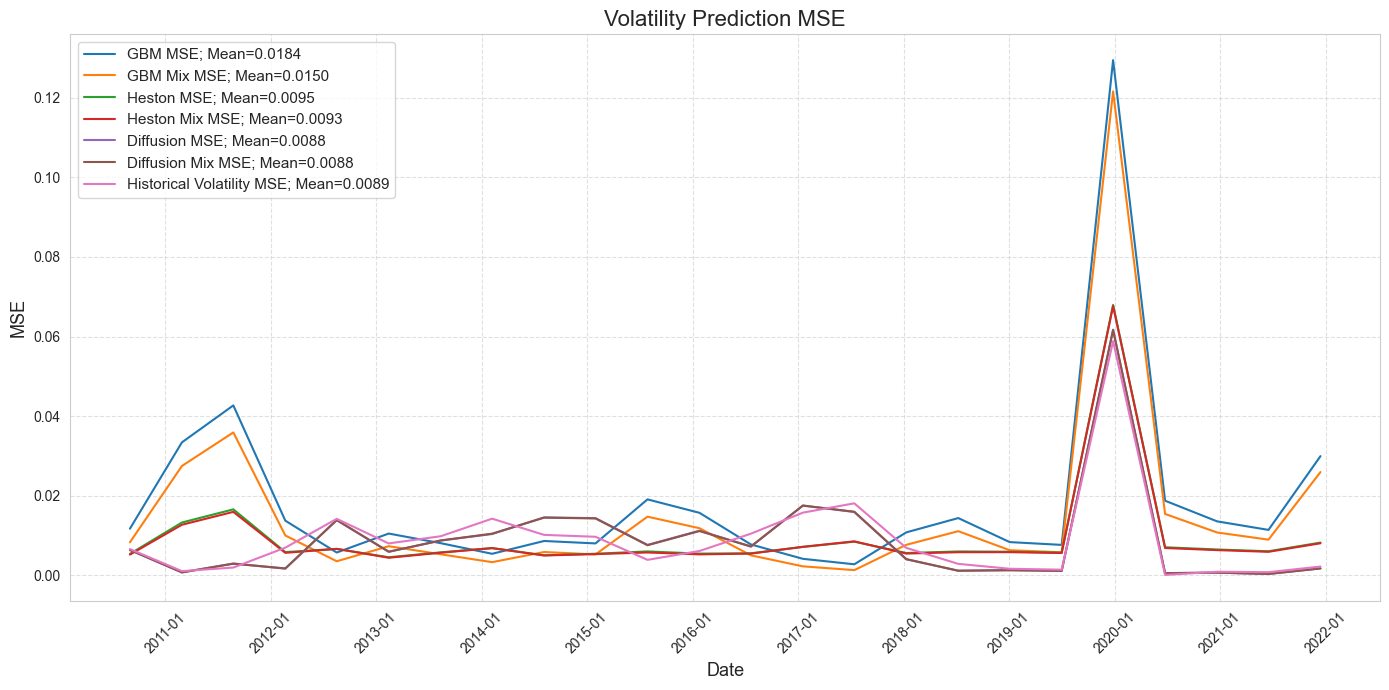

In [26]:
plt.figure(figsize=(14, 7))

vol_preds = [
    ("GBM_vol_mse", "GBM"),
    ("GBM_vol_mse_mix", "GBM Mix"),
    ("Heston_vol_mse", "Heston"),
    ("Heston_vol_mse_mix", "Heston Mix"),
    ("diffusion_vol_mse", "Diffusion"),
    ("diffusion_vol_mse_mix", "Diffusion Mix"),
    ("hist_vol_mse", "Historical Volatility")
]

for col, label in vol_preds:
    plt.plot(df_results['test_start_date'], df_results[col], label=f'{label} MSE; Mean={df_results[col].mean():.4f}')
plt.title("Volatility Prediction MSE", fontsize=16)
plt.xlabel("Date", fontsize=13)
plt.ylabel("MSE", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=20))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("./plots/diffusion_replace_mc/Volatility_Prediction_MSE.png")
plt.show()